In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn nltk transformers torch

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

import nltk
nltk.download('stopwords')
nltk.download('punkt')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [3]:
df = pd.read_csv("/content/internship_feedback_sentiment.csv")

In [4]:
df.head()

,feedback_id,feedback_text,sentiment_label
0,FB_00001,This internship exceeded my expectations. The ...,positive
1,FB_00002,My mentor was great teacher. The Business Anal...,positive
2,FB_00003,The internship experience was highly beneficia...,positive
3,FB_00004,This internship exceeded my expectations. The ...,positive
4,FB_00005,This internship exceeded my expectations. The ...,positive


In [5]:
df.shape

(2000, 3)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   feedback_id      2000 non-null   object
 1   feedback_text    2000 non-null   object
 2   sentiment_label  2000 non-null   object
dtypes: object(3)
memory usage: 47.0+ KB


In [7]:
df.describe()

,feedback_id,feedback_text,sentiment_label
count,2000,2000,2000
unique,2000,420,3
top,FB_01984,This internship exceeded my expectations. The ...,positive
freq,1,65,1305


In [8]:
print(df.isnull().sum())

feedback_id        0
feedback_text      0
sentiment_label    0
dtype: int64


In [9]:
df.dropna(inplace=True)


In [10]:
df = df.drop("feedback_id", axis =1)

In [12]:
stop_words = set(stopwords.words('english'))

In [13]:
def clean_text(text):

    words = word_tokenize(text.lower())

    filtered_words = []

    for word in words:
        if word.isalnum() and word not in stop_words:
            filtered_words.append(word)

    return " ".join(filtered_words)

In [15]:
import nltk
nltk.download('punkt_tab')
df['Cleaned_Feedback'] = df['feedback_text'].apply(clean_text)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [16]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['Cleaned_Feedback'])

In [21]:
y = df['sentiment_label']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [25]:
predictions = model.predict(X_test)

In [26]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [27]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        43
     neutral       1.00      1.00      1.00        93
    positive       1.00      1.00      1.00       264

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [28]:
cm = confusion_matrix(y_test, predictions)

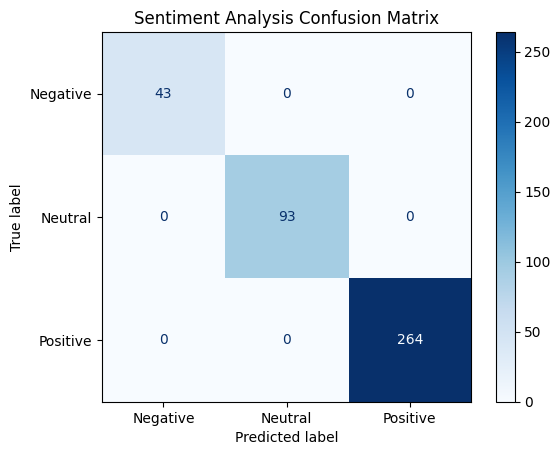

In [30]:
labels = ['Negative', 'Neutral', 'Positive']

cmd = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

cmd.plot(cmap='Blues')

plt.title("Sentiment Analysis Confusion Matrix")

plt.show()

In [44]:
new_feedback = ["The internship experience was very helpful and amazing"]

In [45]:
cleaned_feedback = []

for text in new_feedback:
    cleaned_feedback.append(clean_text(text))

In [46]:
vectorized_feedback = vectorizer.transform(cleaned_feedback)

In [47]:
prediction = model.predict(vectorized_feedback)

print("Predicted Sentiment:", prediction[0])

Predicted Sentiment: positive


In [48]:
feature_names = vectorizer.get_feature_names_out()

coefficients = model.coef_[0]

top_features = pd.DataFrame({
    'Word': feature_names,
    'Importance': coefficients
})

print(top_features.sort_values(by='Importance', ascending=False).head(10))

              Word  Importance
89           needs    1.896974
3         affected    1.753360
116  significantly    1.753360
138  unfortunately    1.485000
50           faced    1.485000
20      challenges    1.485000
34       difficult    1.474031
16         benefit    1.417657
56           fully    1.417657
35   disappointing    1.367256


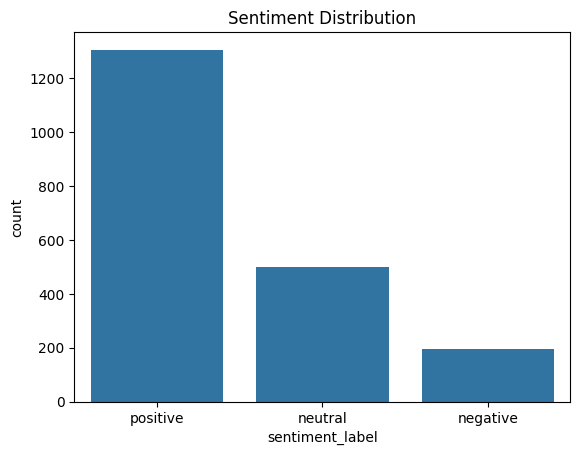

In [50]:
sns.countplot(x='sentiment_label', data=df)

plt.title("Sentiment Distribution")

plt.show()

In [51]:
pip install transformers

In [52]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis")

result = classifier("The internship was excellent")

print(result)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9997872710227966}]
